#  Traffic Sign Detection using Machine Learning

##  Project Overview
This project focuses on building a machine learning model to classify traffic signs from images.

##  Objective
- Perform image preprocessing
- Train a classification model
- Predict traffic sign categories accurately

## IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import zipfile
import requests

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

## DOWNLOAD DATASET

In [2]:
url = "https://d3ilbtxij3aepc.cloudfront.net/projects/AI-Capstone-Projects/PRAICP-1002-TrafSignDetc.zip"
zip_path = "traffic_signs.zip"

if not os.path.exists(zip_path):
    print("Downloading dataset...")
    r = requests.get(url)
    with open(zip_path, "wb") as f:
        f.write(r.content)
    print("Download complete!")
else:
    print("Dataset already downloaded")

Dataset already downloaded


## EXTRACT DATASET

In [3]:
if not os.path.exists("dataset"):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("dataset")
    print("Extraction completed!")
else:
    print("Already extracted")

Already extracted


In [4]:
#CHECK DATA STRUCTURE
print(os.listdir("dataset"))

['Meta', 'Meta.csv', 'Test', 'Test.csv', 'Train', 'Train.csv']


## LOAD TRAIN DATA

In [5]:
data = []
labels = []

IMG_SIZE = 32
dataset_path = "dataset/Train"

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if not os.path.isdir(folder_path):
        continue

    for img in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img)

        try:
            image = cv2.imread(img_path)

            if image is None:
                continue

            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

            data.append(image)
            labels.append(int(folder))

        except:
            pass

data = np.array(data)
labels = np.array(labels)

print("Total images:", len(data))

Total images: 39209


##  Data Preprocessing

- Normalize pixel values (0–255 → 0–1)
- Convert labels to categorical
- Split dataset into train & test

In [6]:
data = data / 255.0
labels = to_categorical(labels)

X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (31367, 32, 32, 3)
Test shape: (7842, 32, 32, 3)


## ADVANCED CNN MODEL

In [7]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(len(labels[0]), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\admin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 30, 30, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 13, 13, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 4, 4, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 43)                  │          11,051 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 236,523 (923.92 KB)

 Trainable params: 236,075 (922.17 KB)

 Non-trainable params: 448 (1.75 KB)

## TRAIN MODEL

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    validation_data=(X_test, y_test),
    batch_size=64
)

Epoch 1/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 55s 82ms/step - accuracy: 0.7588 - loss: 0.8713 - val_accuracy: 0.9260 - val_loss: 0.2660
Epoch 2/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 47s 96ms/step - accuracy: 0.9666 - loss: 0.1100 - val_accuracy: 0.9804 - val_loss: 0.0699
Epoch 3/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 34s 68ms/step - accuracy: 0.9794 - loss: 0.0656 - val_accuracy: 0.9814 - val_loss: 0.0605
Epoch 4/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 34s 69ms/step - accuracy: 0.9872 - loss: 0.0413 - val_accuracy: 0.9899 - val_loss: 0.0365
Epoch 5/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 33s 68ms/step - accuracy: 0.9866 - loss: 0.0415 - val_accuracy: 0.9904 - val_loss: 0.0303
Epoch 6/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 36s 73ms/step - accuracy: 0.9895 - loss: 0.0321 - val_accuracy: 0.9774 - val_loss: 0.0712
Epoch 7/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 35s 71ms/step - accuracy: 0.9903 - loss: 0.0296 - val_accuracy: 0.9918 - val_loss: 0.0292
Epoch 8/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 34s 69ms/step - accuracy: 0.9922 - loss: 0.0271 - 

## ACCURACY GRAPH

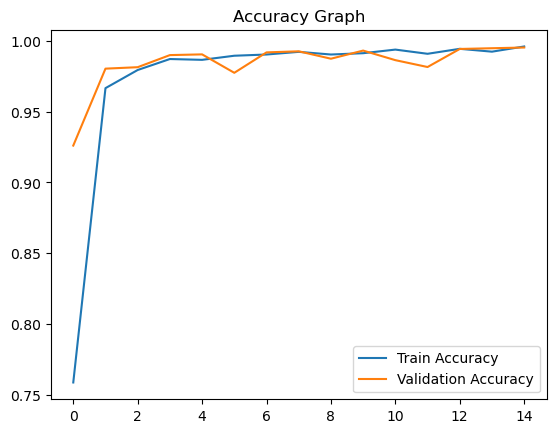

In [9]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

## EVALUATION

In [10]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Accuracy:", accuracy_score(y_true, y_pred_classes))
print(classification_report(y_true, y_pred_classes))

246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
Accuracy: 0.9952818158633002
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        38
           1       1.00      0.99      0.99       496
           2       0.99      1.00      0.99       420
           3       1.00      1.00      1.00       294
           4       1.00      1.00      1.00       400
           5       0.98      0.99      0.98       364
           6       1.00      1.00      1.00        69
           7       1.00      1.00      1.00       313
           8       1.00      0.99      0.99       274
           9       1.00      1.00      1.00       277
          10       1.00      1.00      1.00       398
          11       1.00      0.99      0.99       261
          12       0.99      1.00      1.00       443
          13       0.99      1.00      1.00       422
          14       1.00      0.99      0.99       135
          15       1.00      0.99      1.00       118
          

## CONFUSION MATRIX

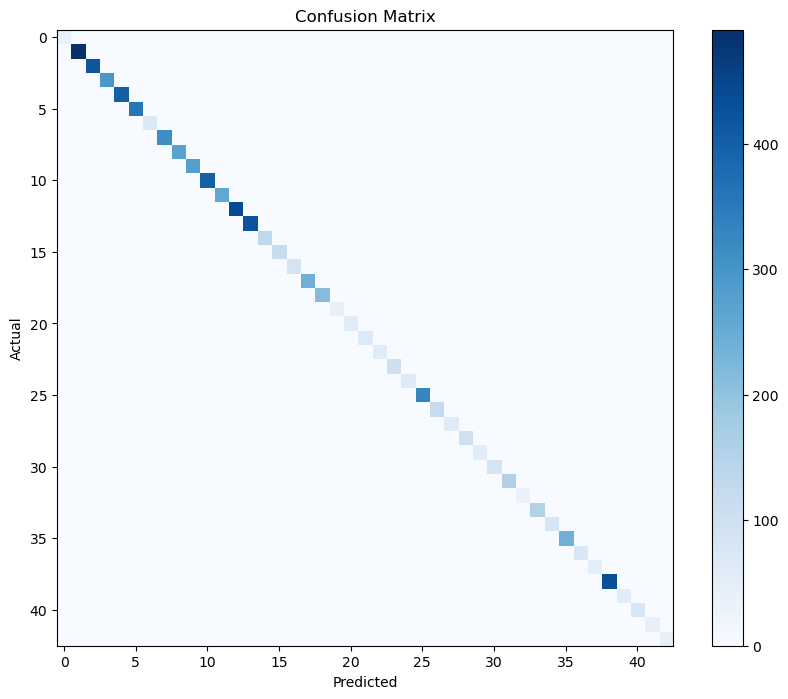

In [11]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## PREDICTION FUNCTION

In [13]:
def predict_image(img_path):
    import os
    
    # Check if file exists
    if not os.path.exists(img_path):
        print("❌ Image not found:", img_path)
        return None

    img = cv2.imread(img_path)

    # Check if image loaded
    if img is None:
        print("❌ Unable to read image")
        return None

    img = cv2.resize(img, (32,32))
    img = img / 255.0
    img = np.reshape(img, (1,32,32,3))

    pred = model.predict(img)
    return np.argmax(pred)

In [14]:
predict_image("dataset/Test/00001.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


np.int64(1)

In [18]:
predict_image("dataset/Test/00003.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


np.int64(33)

In [15]:
import os
print(os.listdir("dataset/Test")[:10])

['00000.png', '00001.png', '00002.png', '00003.png', '00004.png', '00005.png', '00006.png', '00007.png', '00008.png', '00009.png']


In [17]:
classes = ["Speed Limit", "Stop", "Yield", ...]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


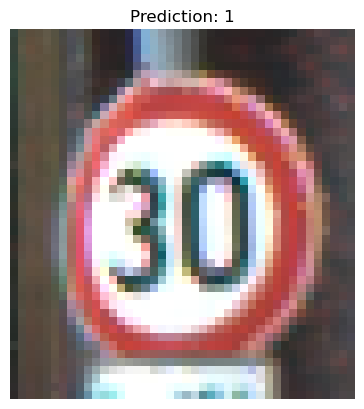

In [16]:
def predict_and_show(img_path):
    img = cv2.imread(img_path)
    
    if img is None:
        print("Image not found")
        return
    
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Prediction: {predict_image(img_path)}")
    plt.axis('off')
    plt.show()

# Example
predict_and_show("dataset/Test/00001.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


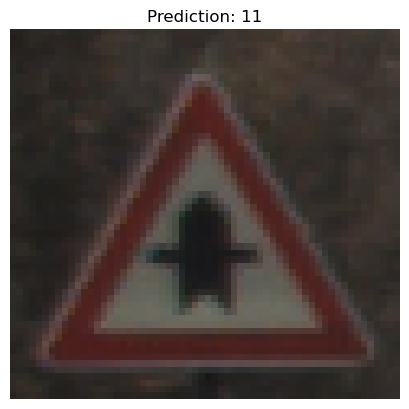

In [20]:
predict_and_show("dataset/Test/00004.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


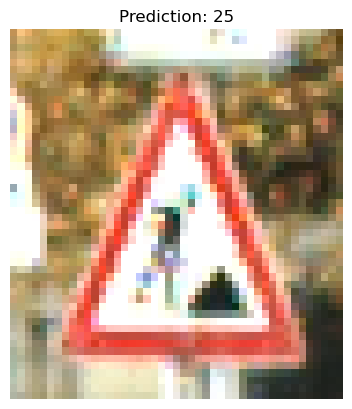

In [21]:
predict_and_show("dataset/Test/00008.png")

## Conclusion & Further Improvements

We achieved a strong baseline with a custom CNN.

Data augmentation and callbacks helped improve generalization.

To boost accuracy further, we could:

Use transfer learning (e.g., VGG16, ResNet) pretrained on ImageNet.

Increase image resolution (e.g., 128x128).

Perform hyperparameter tuning.

Use ensemble methods.